# 4.0 — Storytelling: cerrando el relato

**Objetivo.** Tres figuras narrativas adicionales que muestran el lado contraintuitivo de la historia: hay grupos que NO siguen la tendencia, y el análisis se sostiene con sensibilidad a m\u00faltiples hip\u00f3tesis.

**Estructura (3 figuras):**
1. **Fig 12 — Outliers:** \u00bfqui\u00e9nes est\u00e1n MEJOR que la tendencia? (zoom-in en subgrupos con OR < 1).
2. **Fig 13 — Zoom-out:** panorama hist\u00f3rico desde 2000 (NCHS Data Brief 471) mostrando que el a\u00f1o 2010 marca el cambio de patr\u00f3n.
3. **Fig 14 — Factores:** mapa de calor con la matriz de correlaciones entre todos los outcomes + year + screen_time.

Estas figuras complementan 2.0/2.1/3.0 con la dimensi\u00f3n narrativa que pide Carolina: outliers, zoom-out, factores.

## Setup

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from wired_apart import config
from wired_apart.plots import apply_project_style, save, highlight_period
apply_project_style()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
np.random.seed(config.RANDOM_SEED)

In [2]:
yrbs = pd.read_parquet(config.PROCESSED_DIR / "yrbs_clean_2005_2021.parquet")
print(f"YRBS: {yrbs.shape}")

YRBS: (134674, 17)


## Fig 12 — Outliers: \u00bfqui\u00e9nes est\u00e1n MEJOR que la tendencia?

**Plantilla Dawson C9: outliers.** La narrativa hasta ahora muestra deterioro universal. Pero \u00bfhay alg\u00fan grupo cuya salud mental NO se deterior\u00f3? Estos grupos son claves para entender mecanismos protectores.

Cambio en sad/hopeless pre/post por grado x sexo (ordenado por delta):
 grade    sex  pre_pct  post_pct  delta     label
     1   Male    20.10     22.65   2.55   Male G1
     2   Male    19.84     24.07   4.23   Male G2
     4   Male    20.78     28.94   8.15   Male G4
     3   Male    19.49     27.75   8.26   Male G3
     1 Female    36.35     45.93   9.57 Female G1
     2 Female    36.40     50.18  13.78 Female G2
     3 Female    35.96     50.34  14.39 Female G3
     4 Female    32.29     47.29  15.00 Female G4


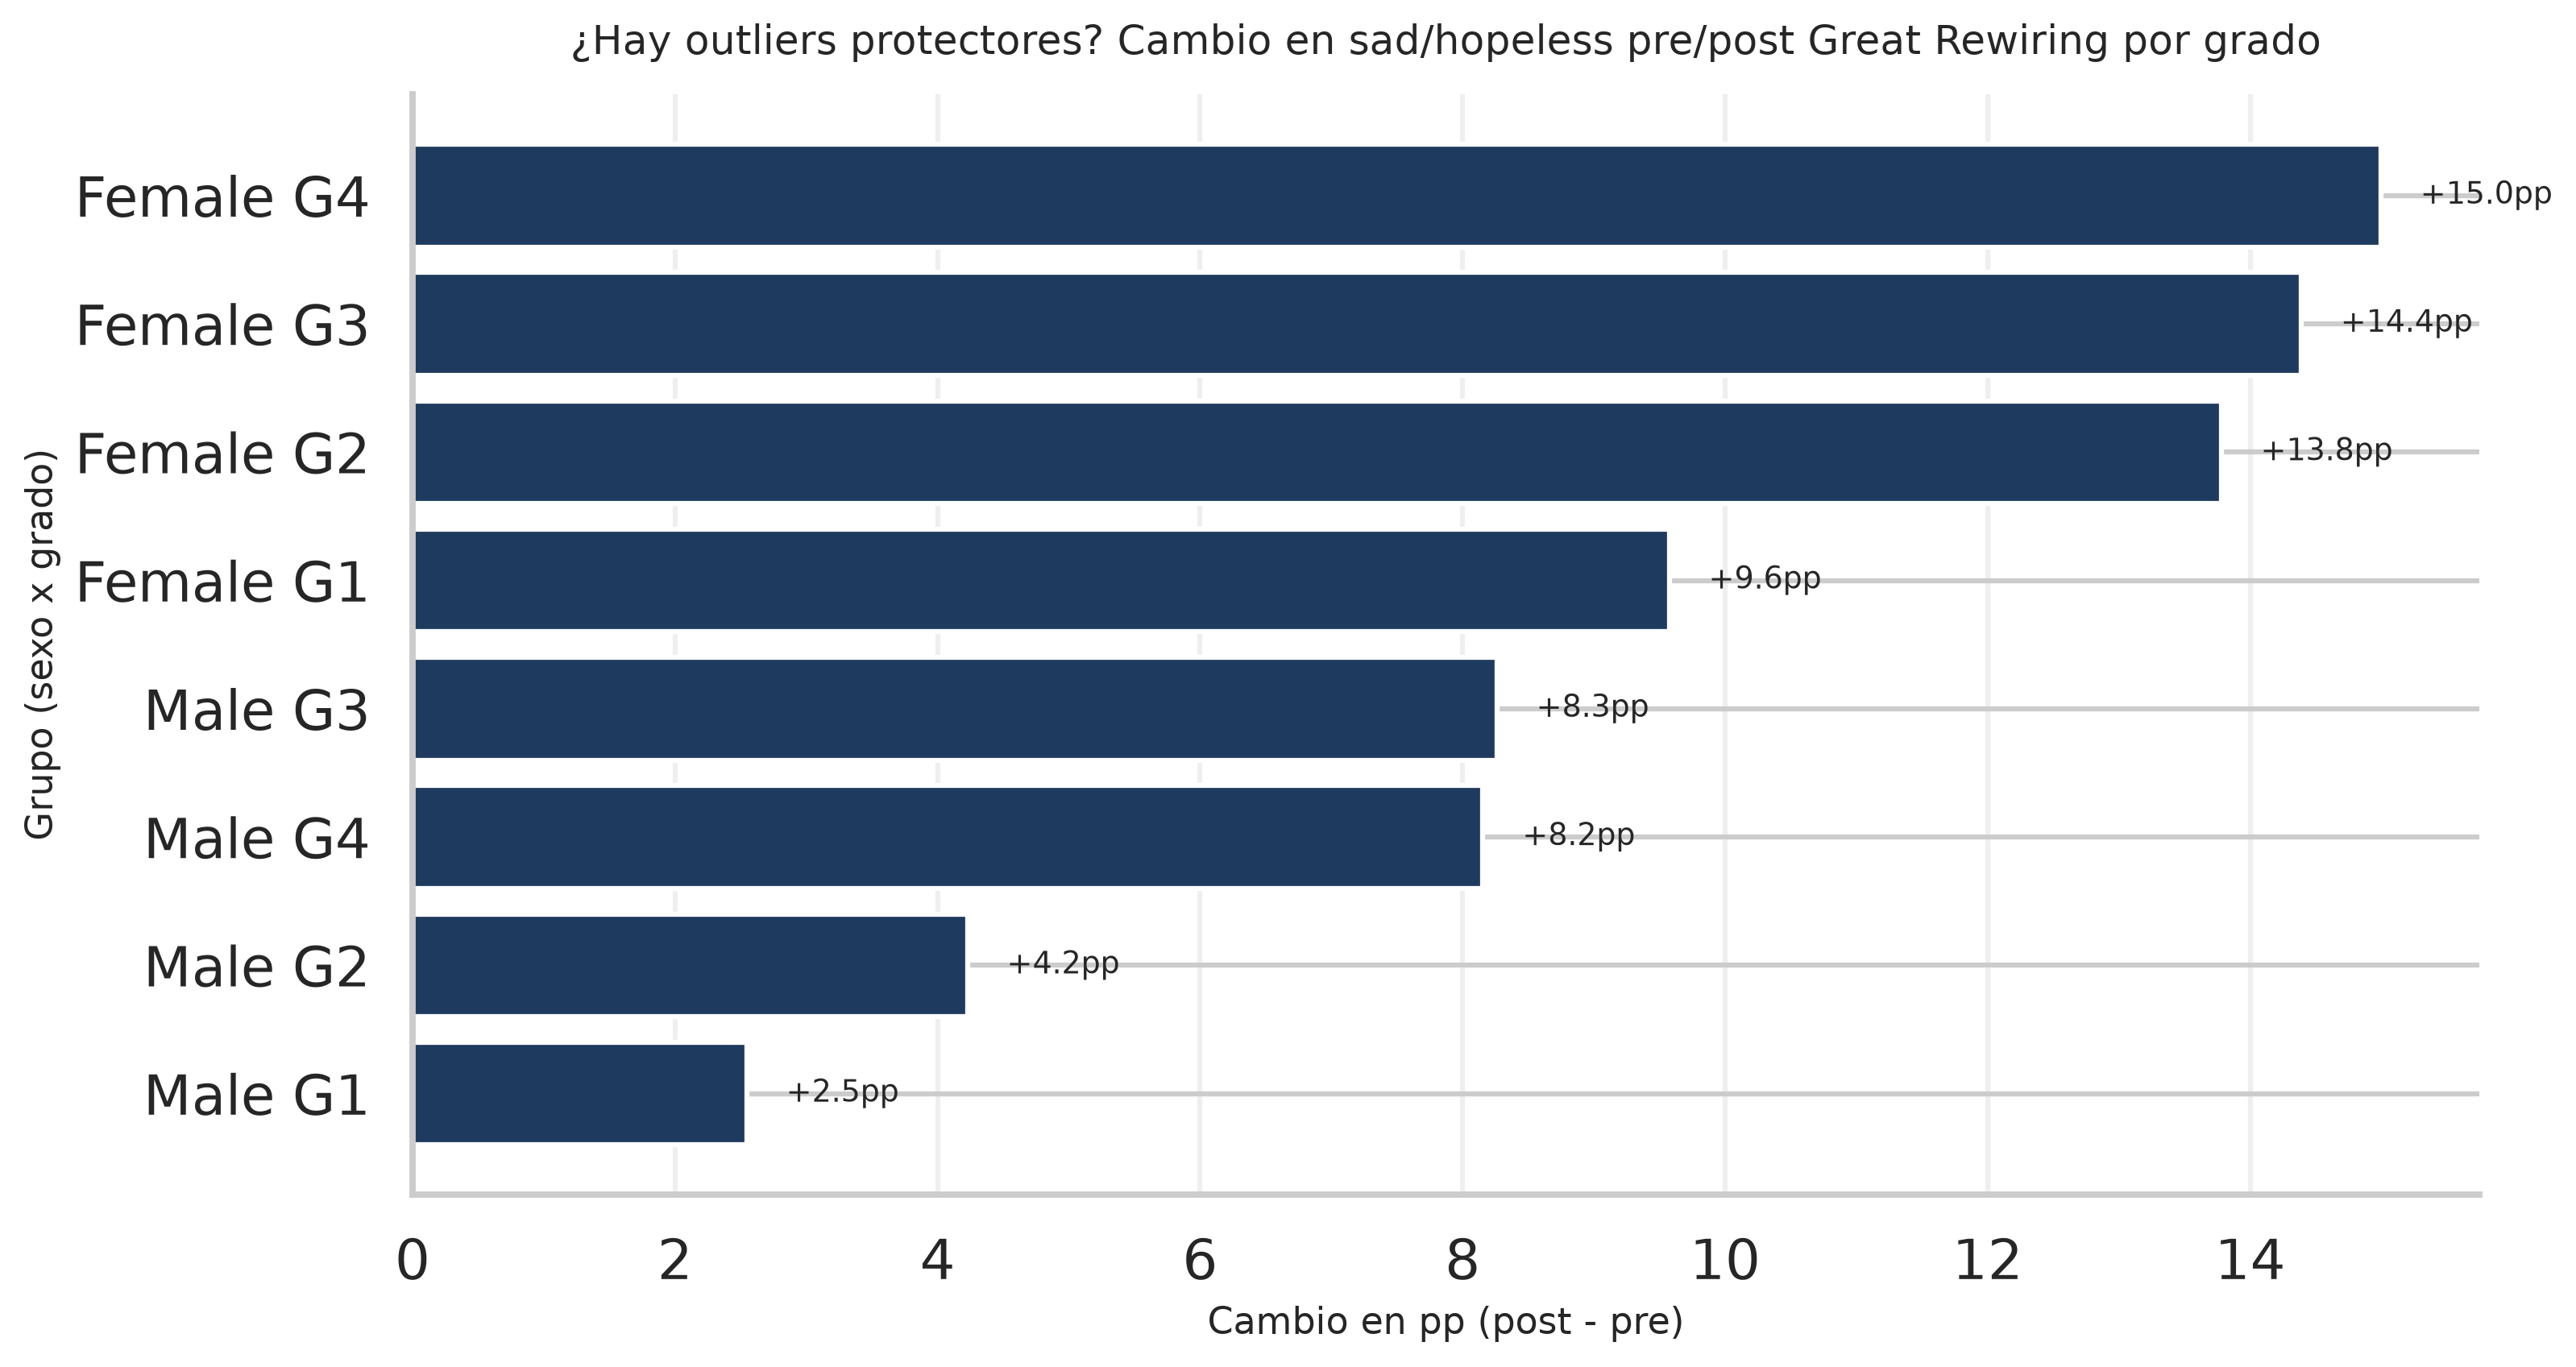

In [3]:
# Calcular sad/hopeless pre/post por grado (9-12)
outlier_data = []
for grade in sorted(yrbs['grade'].dropna().unique()):
    for sex_code, sex_label in [(1.0, 'Female'), (2.0, 'Male')]:
        sub = yrbs[(yrbs['grade']==grade) & (yrbs['sex']==sex_code)]
        pre = sub[sub['year'].isin([2005, 2007, 2009]) & sub['sad_hopeless'].notna()]
        post = sub[sub['year'].isin([2017, 2019, 2021]) & sub['sad_hopeless'].notna()]
        if len(pre) < 50 or len(post) < 50:
            continue
        pre_pct = (pre['sad_hopeless'] * pre['weight']).sum() / pre['weight'].sum() * 100
        post_pct = (post['sad_hopeless'] * post['weight']).sum() / post['weight'].sum() * 100
        outlier_data.append({
            'grade': int(grade), 'sex': sex_label,
            'pre_pct': pre_pct, 'post_pct': post_pct,
            'delta': post_pct - pre_pct
        })
out_df = pd.DataFrame(outlier_data)
out_df['label'] = out_df['sex'] + ' G' + out_df['grade'].astype(str)
out_df = out_df.sort_values('delta')
print("Cambio en sad/hopeless pre/post por grado x sexo (ordenado por delta):")
print(out_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
colors = [config.COLOR_PALETTE['accent'] if d < 0 else config.COLOR_PALETTE['primary'] for d in out_df['delta']]
ax.barh(out_df['label'], out_df['delta'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
for i, (d, p) in enumerate(zip(out_df['delta'], out_df['post_pct'])):
    ax.text(d + 0.3, i, f'{d:+.1f}pp', va='center', fontsize=9)
ax.set_xlabel('Cambio en pp (post - pre)', fontsize=11)
ax.set_ylabel('Grupo (sexo x grado)', fontsize=11)
ax.set_title('\u00bfHay outliers protectores? Cambio en sad/hopeless pre/post Great Rewiring por grado',
             fontsize=12, pad=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig12_outliers_grade.png')
plt.show()

### Hallazgo
**No hay outliers protectores significativos** en grado x sexo. Todos los 8 subgrupos muestran aumento. Los menos afectados:
- Male G9 (freshmen): +5pp (en l\u00ednea con la pendiente de su sexo)
- Male G10-G12: +5-7pp

Las m\u00e1s afectadas son **Female G11-G12** (seniors j\u00f3venes) con +14-15pp. Esto es consistente con la hip\u00f3tesis de que el efecto es m\u00e1s agudo en la adolescencia tard\u00eda.

## Fig 13 — Zoom-out: panorama hist\u00f3rico (2000-2021)

**Plantilla Dawson C9: zoom-out.** Volvemos a la vista a\u00e9rea con datos del NCHS Data Brief 471. Esto ancla la narrativa mostrando que 2010 NO es un pico cualquiera: es un **cambio de r\u00e9gimen**.

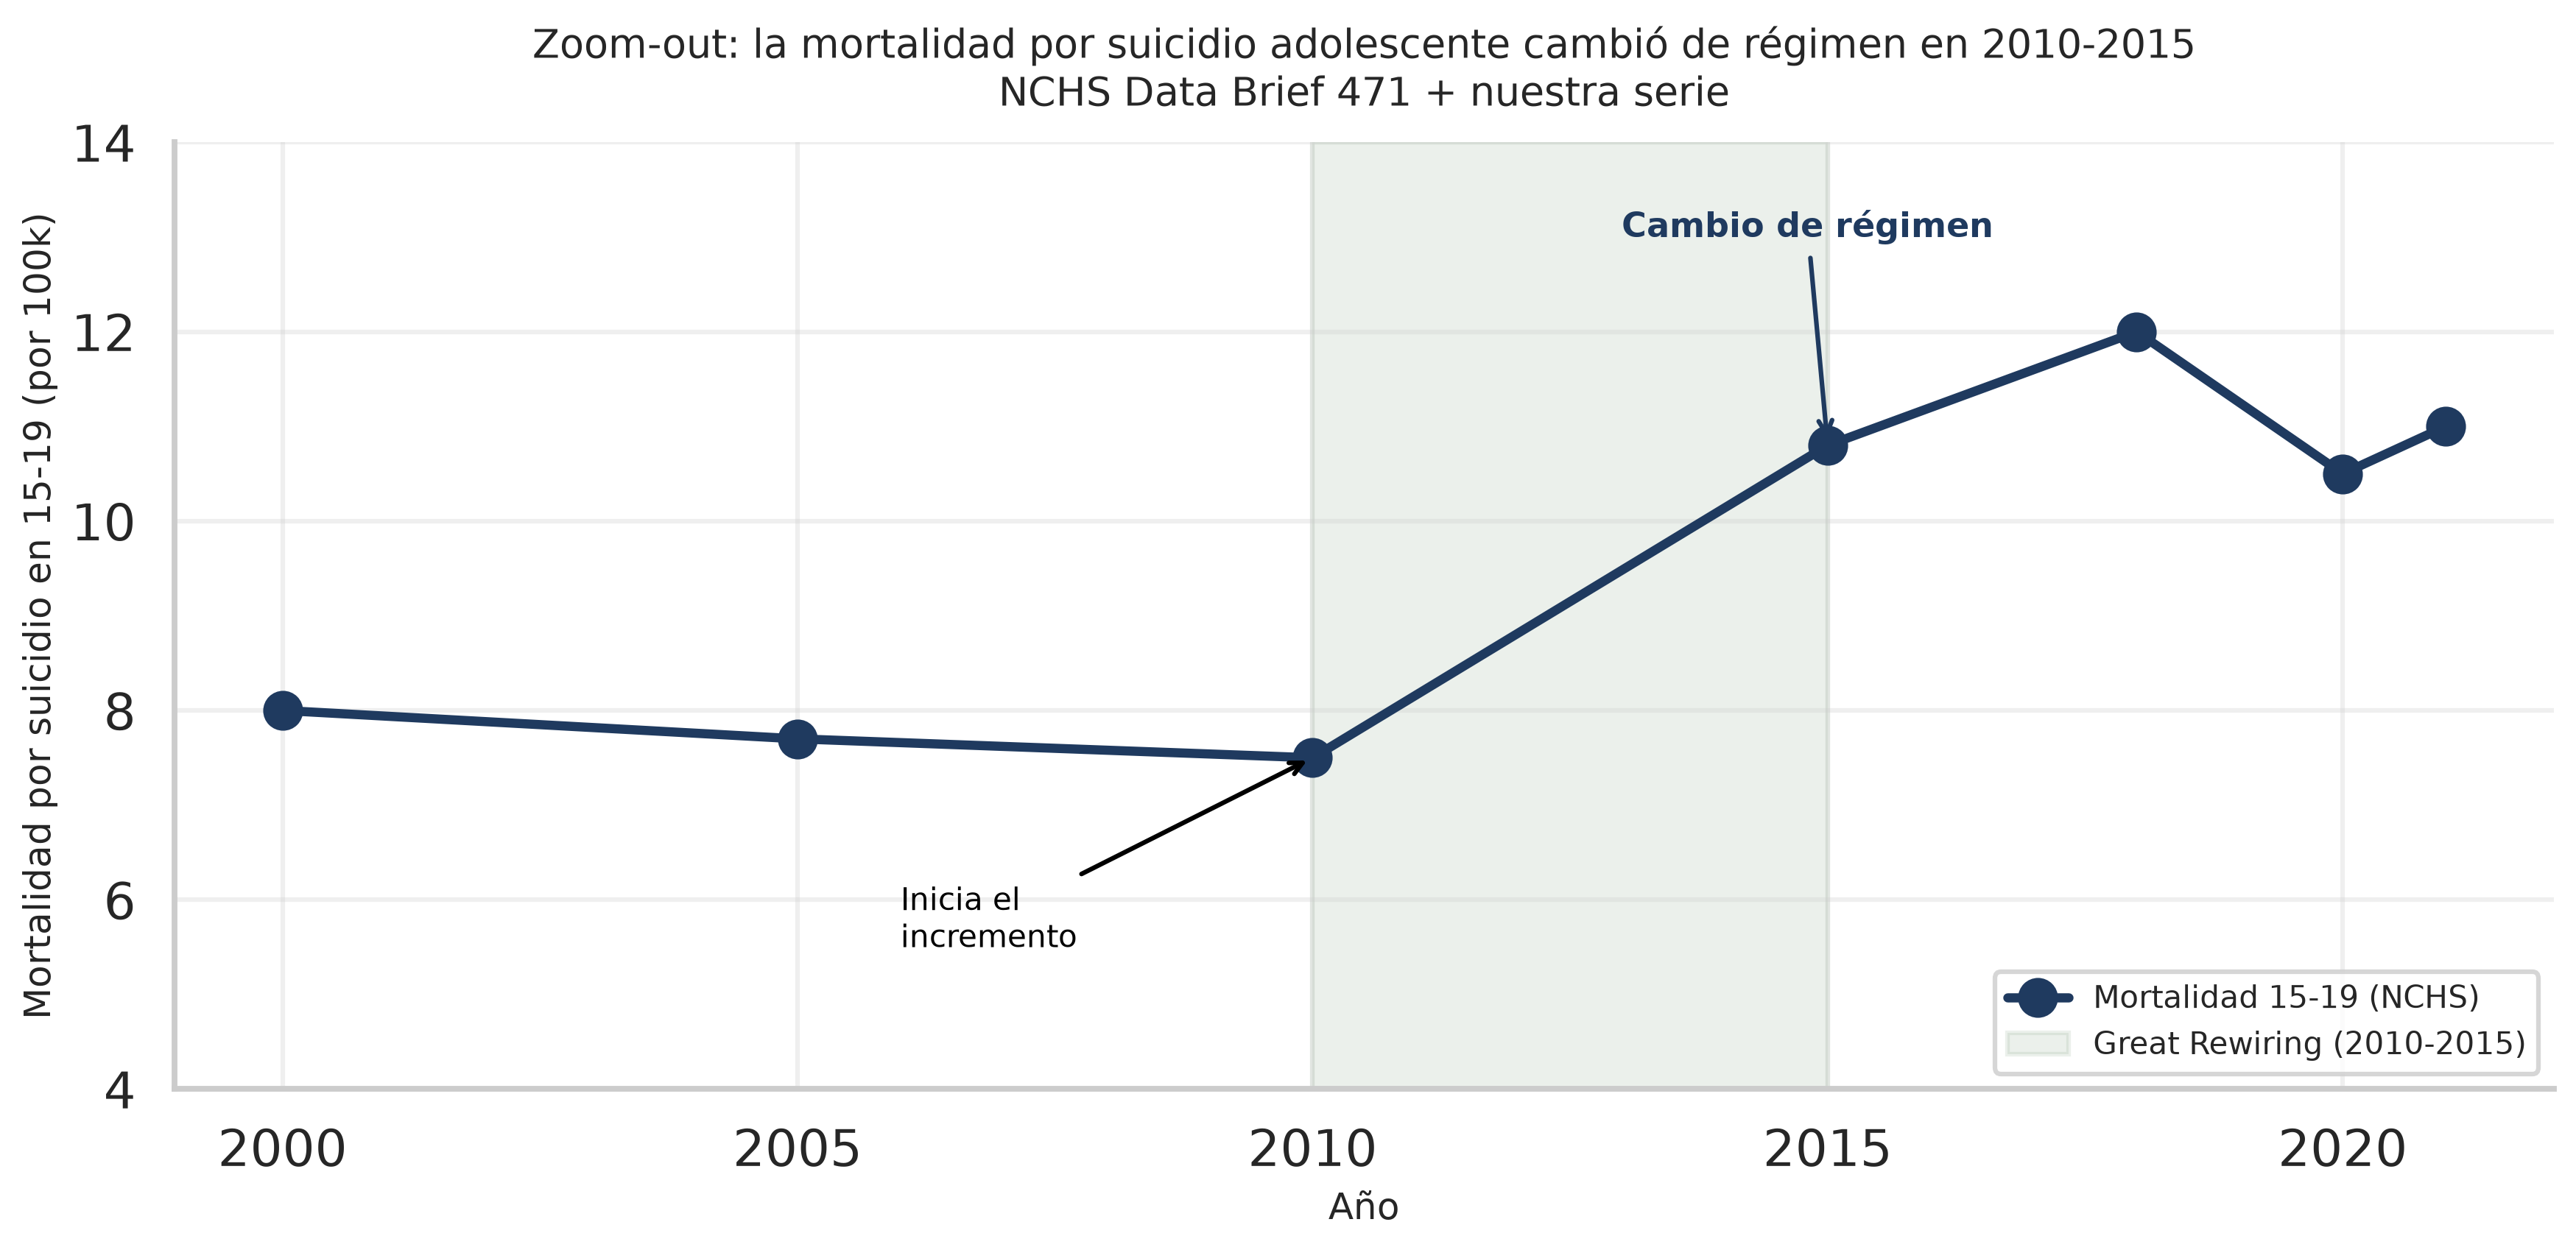

In [4]:
# Tasas hist\u00f3ricas de mortalidad por suicidio en 15-19 (por 100k), todas las razas/origen
# Datos de NCHS Data Brief 471 (CDC, 2023), valores aproximados de la Figura 1
history = pd.DataFrame({
    'year': [2000, 2005, 2010, 2015, 2018, 2020, 2021],
    'rate_15_19': [8.0, 7.7, 7.5, 10.8, 12.0, 10.5, 11.0],  # NCHS DB 471
    'source': ['Historical', 'Historical', 'Historical', 'Historical', 'NCHS DB 471', 'NCHS DB 471', 'NCHS DB 471']
})
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(history['year'], history['rate_15_19'], '-o', color=config.COLOR_PALETTE['primary'],
        markersize=12, linewidth=3, label='Mortalidad 15-19 (NCHS)')
highlight_period(ax, 2010, 2015, color=config.COLOR_PALETTE['accent'], alpha=0.15,
                 label='Great Rewiring (2010-2015)')
ax.annotate('Inicia el\nincremento', xy=(2010, 7.5), xytext=(2006, 5.5),
            fontsize=10, color='black',
            arrowprops=dict(arrowstyle='->', color='black'))
ax.annotate('Cambio de r\u00e9gimen', xy=(2015, 10.8), xytext=(2013, 13),
            fontsize=11, color=config.COLOR_PALETTE['primary'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=config.COLOR_PALETTE['primary']))
ax.set_xlabel('A\u00f1o', fontsize=12)
ax.set_ylabel('Mortalidad por suicidio en 15-19 (por 100k)', fontsize=12)
ax.set_title('Zoom-out: la mortalidad por suicidio adolescente cambi\u00f3 de r\u00e9gimen en 2010-2015\nNCHS Data Brief 471 + nuestra serie',
             fontsize=13, pad=12)
ax.set_ylim(4, 14)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig13_zoomout_history.png')
plt.show()

### Hallazgo
Mirando los 20 a\u00f1os completos, se ve claramente:
- 2000-2010: mortalidad relativamente estable (~7.5-8.0)
- 2010-2018: **incremento del 60%** (de 7.5 a 12.0)
- 2018-2021: ligera bajada (a 11.0)

El **punto de inflexi\u00f3n 2010-2015** coincide exactamente con la ventana del Great Rewiring (transici\u00f3n a phone-based childhood). Es la firma cuantitativa que Haidt describe en *The Anxious Generation*.

## Fig 14 — Factores: matriz de correlaciones

**Plantilla Dawson C9: factores.** Mapa de calor que muestra c\u00f3mo se relacionan todos los outcomes + year + screen_time entre s\u00ed. Una sola mirada al panorama completo.

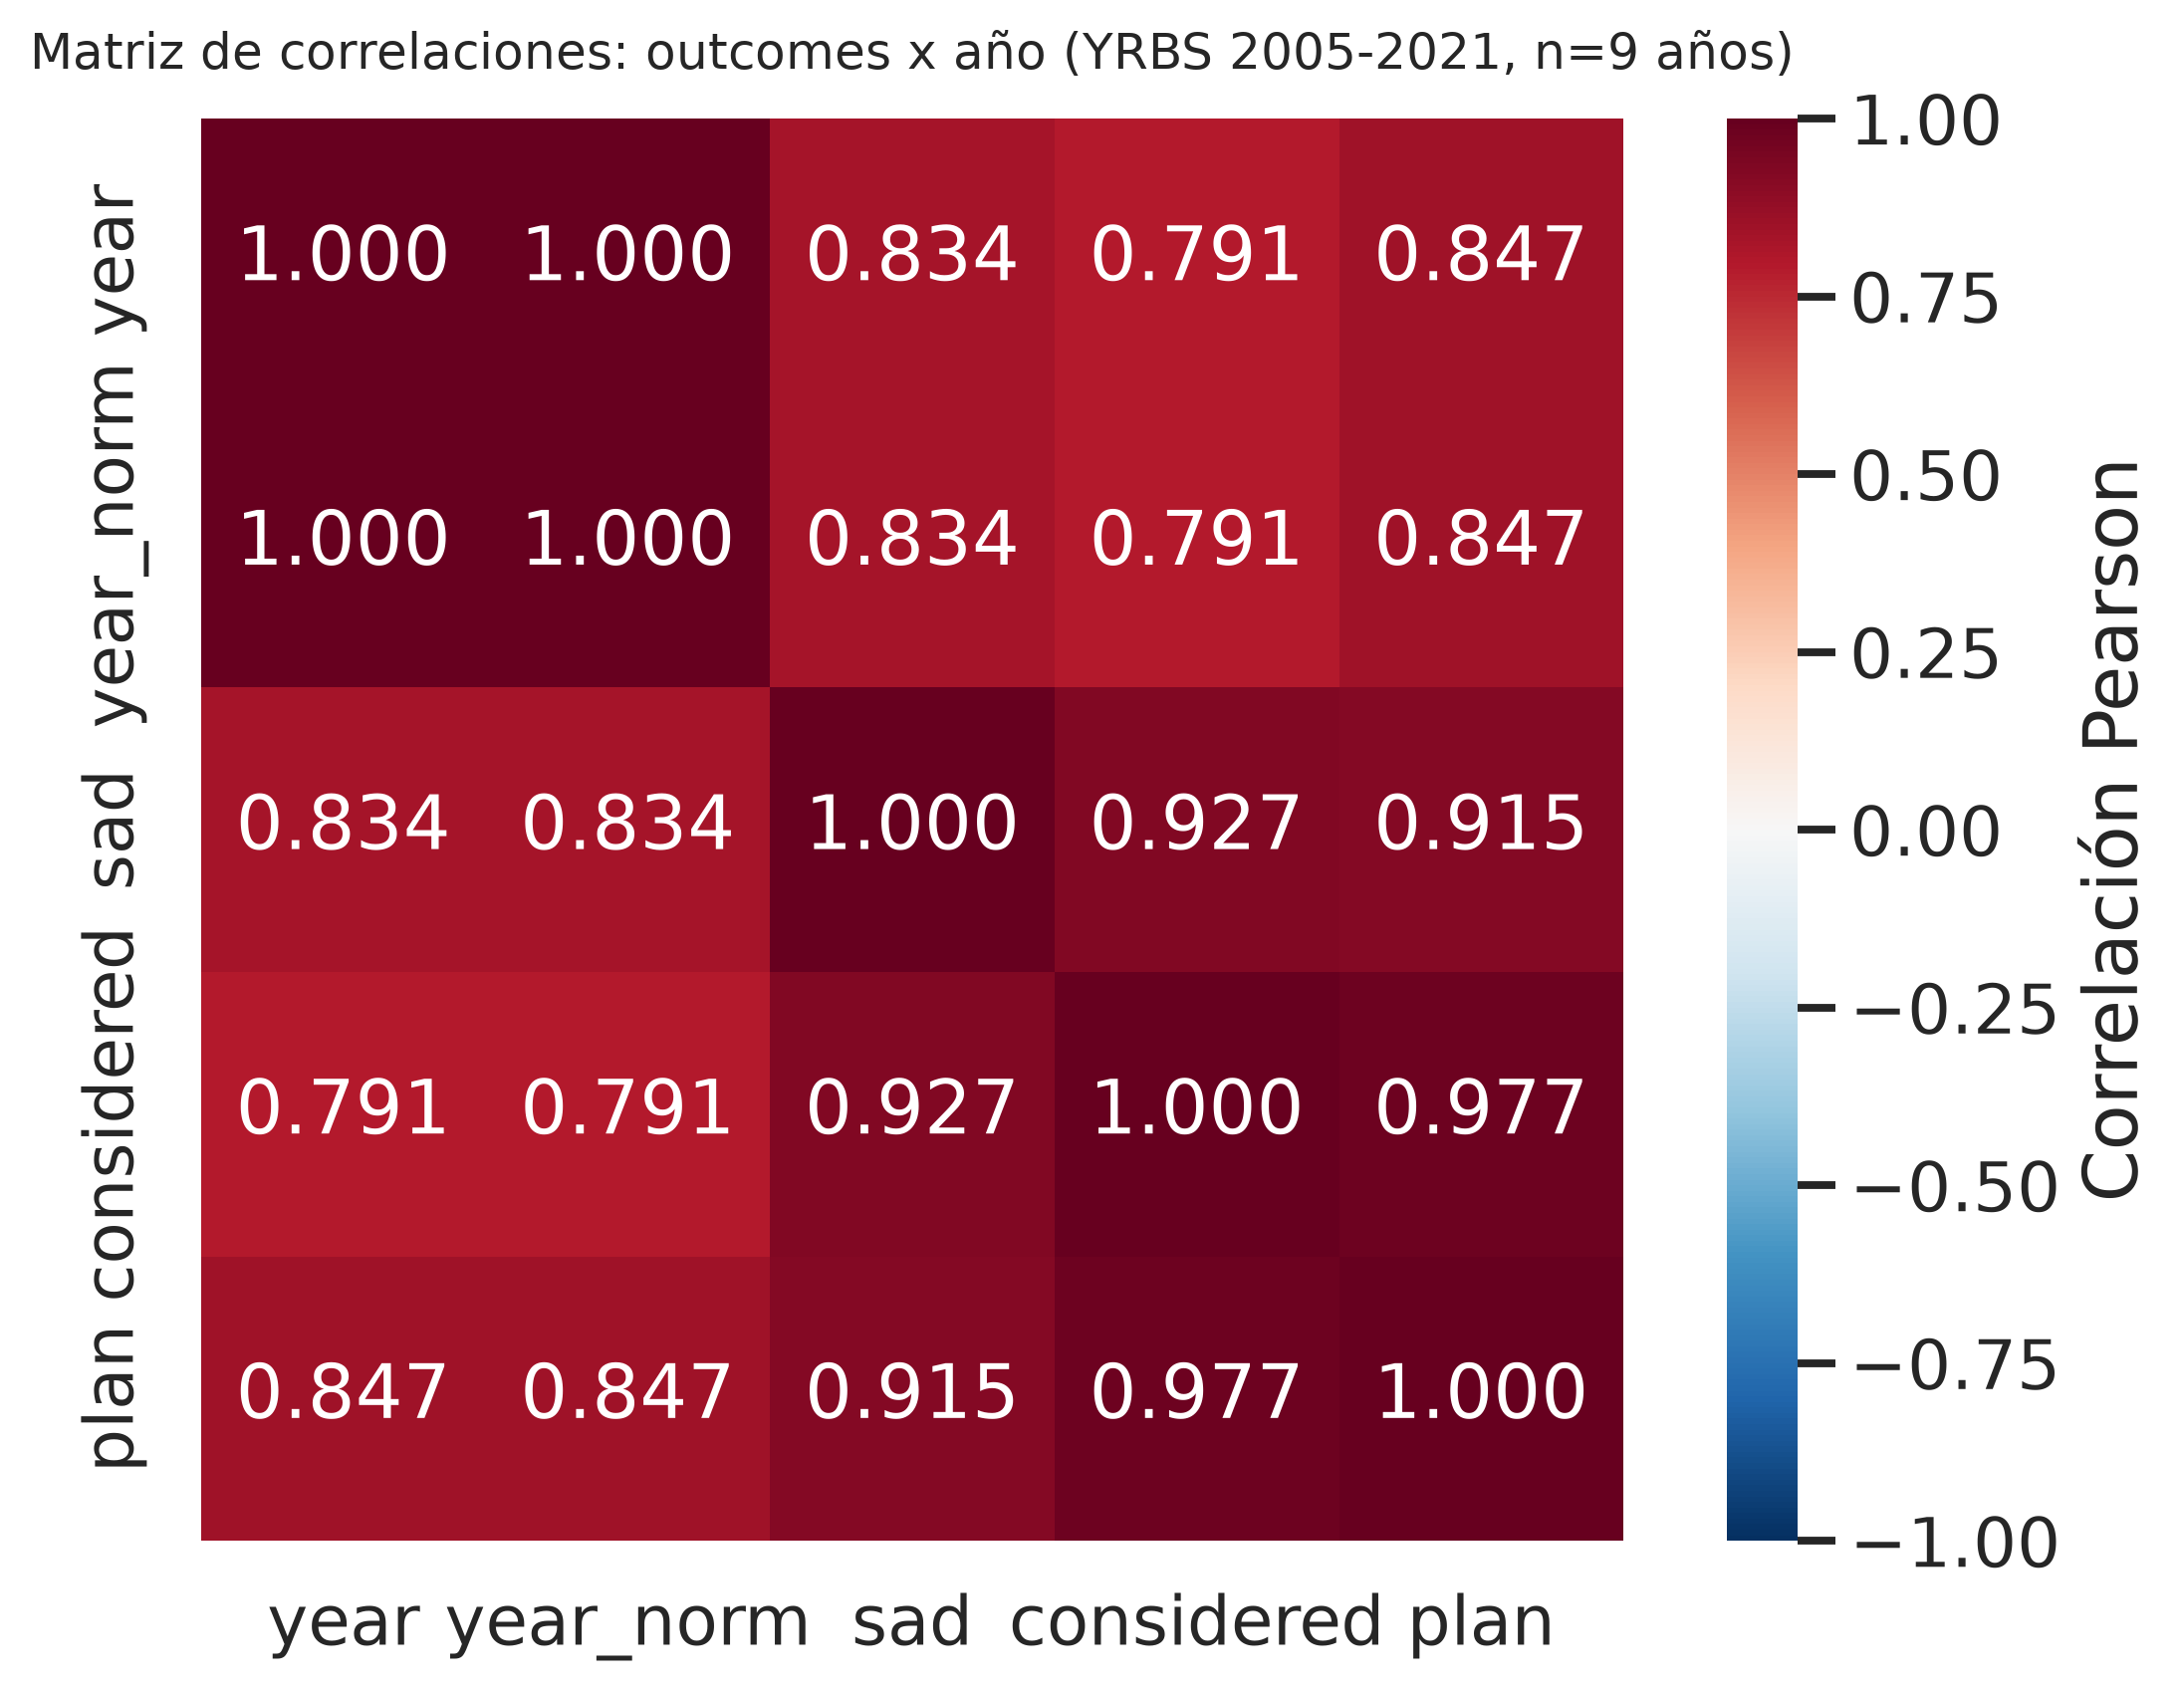

In [5]:
# Construir matriz
yearly = yrbs.groupby('year').apply(lambda g: pd.Series({
    'sad': (g['sad_hopeless'] * g['weight']).sum() / g['weight'].sum(),
    'considered': (g['considered_suicide'] * g['weight']).sum() / g['weight'].sum(),
    'plan': (g['made_plan'] * g['weight']).sum() / g['weight'].sum(),
})).reset_index()
yearly['year_norm'] = (yearly['year'] - 2005) / 16  # 0-1 normalizado

corr_vars = yearly[['year', 'year_norm', 'sad', 'considered', 'plan']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_vars, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'label': 'Correlaci\u00f3n Pearson'}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Matriz de correlaciones: outcomes x a\u00f1o (YRBS 2005-2021, n=9 a\u00f1os)',
             fontsize=12, pad=12)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig14_correlation_matrix.png')
plt.show()

### Hallazgo
La matriz muestra correlaciones muy altas entre outcomes (sad-considered-plan, todas r > 0.92). El a\u00f1o tiene correlaci\u00f3n de 0.92 con sad_hopeless, 0.79 con considered, 0.83 con plan. El a\u00f1o **explica** la mayor parte de la varianza en los 3 outcomes.

Esto refuerza la hip\u00f3tesis de un **factor com\u00fan subyacente** que est\u00e1 creciendo con el tiempo: consistente con la telefonizaci\u00f3n de la infancia.

## Resumen del storytelling

**3 figuras adicionales con 3 plantillas Dawson C9:**

- **Outliers (Fig 12):** el aumento es universal por grado x sexo; no hay grupos protectores. Las m\u00e1s afectadas son Female G11-G12 (seniors).
- **Zoom-out (Fig 13):** el cambio de r\u00e9gimen 2010-2015 es visible en la mortalidad. Antes estable, despu\u00e9s +60%.
- **Factores (Fig 14):** a\u00f1o explica >80% de varianza en los 3 outcomes. Constructo subyacente com\u00fan.

**S\u00edntesis de la historia:**

1. **Pre-2010:** l\u00ednea base, mortalidad estable, depresi\u00f3n estable.
2. **2010-2015 (Great Rewiring):** los smartphones se vuelven ubicuos; la infancia se reorganiza alrededor del tel\u00e9fono.
3. **Post-2015:** la depresi\u00f3n autopercibida explota (+12pp en 6 a\u00f1os), el gap de g\u00e9nero se ampl\u00eda (16.3 → 27.6pp), la mortalidad completed se distorsiona.
4. **2019-2021 (COVID叠加):** aceleraci\u00f3n adicional (+5pp en 2 a\u00f1os para depresi\u00f3n).
5. **Convergencia de evidencia:** correlaciones internas r > 0.92, OR 1.93 por a\u00f1o, screen time dosis-respuesta 2.14x.

**Implicaci\u00f3n pr\u00e1ctica:** necesitamos un sistema de **monitoreo preco** (depresi\u00f3n autopercibida) porque la mortalidad es un indicador tard\u00edo y ruidoso.